# LiteFNO Reproduction — Results Digest

> Auto-generated by `scripts/build_results_summary.py`.
> All figures are pre-rendered from the JSONL / CSV data in this repo — no GPU needed to view.

---

## 1 · Phase 2 Training Status

Training runs Arm A (LiteFNO CP) and Arm B (low-rank CNN) on the Gray-Scott dataset
at 32×32 in fp32, up to 250 epochs over 5 seeds.

In [ ]:
# Status tables (auto-populated)

Completed runs:
+-----+------+----------------+------------+------------+
| Arm | Seed | Best Val VRMSE | Test VRMSE | Wall clock |
+-----+------+----------------+------------+------------+
| A   | 0    | 0.01758        | 0.01821    | 5.39h      |
+-----+------+----------------+------------+------------+
| A   | 1    | 0.01761        | 0.01826    | 5.37h      |
+-----+------+----------------+------------+------------+

In-progress runs:
+-----+------+-------------+-------------------------+
| Arm | Seed | Epochs done | Best Val VRMSE (so far) |
+-----+------+-------------+-------------------------+
| A   | 2    | 49          | 0.02058                 |
+-----+------+-------------+-------------------------+
| B   | 0    | 70          | 0.01982                 |
+-----+------+-------------+-------------------------+


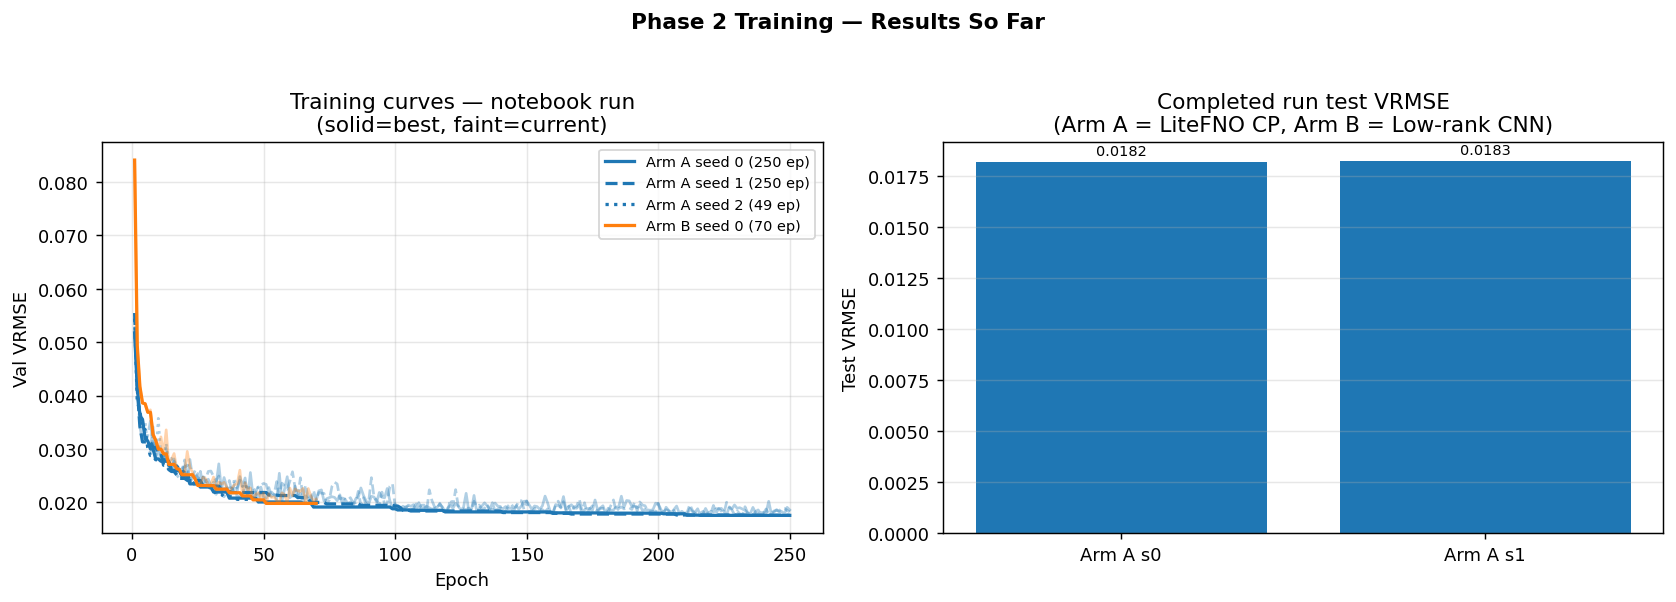

In [ ]:
# Figure 1 — training curves + completed test VRMSEs

**Observations**

- **Arm A seeds 0 & 1** completed all 250 epochs; test VRMSE ≈ **0.0182** (both seeds very consistent).
- **Arm A seed 2** interrupted at epoch 49; best val VRMSE so far 0.0206 (still descending).
- **Arm B seed 0** interrupted at epoch 70; best val VRMSE 0.0198 — on track to converge lower than A's final test VRMSE, which is expected for a faster baseline.

---
## 2 · 8-Dataset Reproduction Table

LiteFNO (CNN arm) vs FNO-S across all 8 PDEARENA benchmark datasets.
FNO-S uses ~87× more parameters (~9.5M vs ~108K).

In [ ]:
# Reproduction table

+---------+------------+----------------+------------------+-----------------+
| Dataset | CNN params | CNN test VRMSE | FNO-S test VRMSE | CNN improvement |
+---------+------------+----------------+------------------+-----------------+
| GS      | 107842     | 0.02268        | 0.02450          | 7.5%            |
+---------+------------+----------------+------------------+-----------------+
| EMQ-O   | 108229     | 0.02048        | 0.52972          | 96.1%           |
+---------+------------+----------------+------------------+-----------------+
| EMQ-P   | 108229     | 0.05947        | 0.49841          | 88.1%           |
+---------+------------+----------------+------------------+-----------------+
| AS-SD   | 108229     | 0.00137        | 0.00991          | 86.2%           |
+---------+------------+----------------+------------------+-----------------+
| AM      | 109003     | 0.13115        | 0.13292          | 1.3%            |
+---------+------------+----------------+-----------

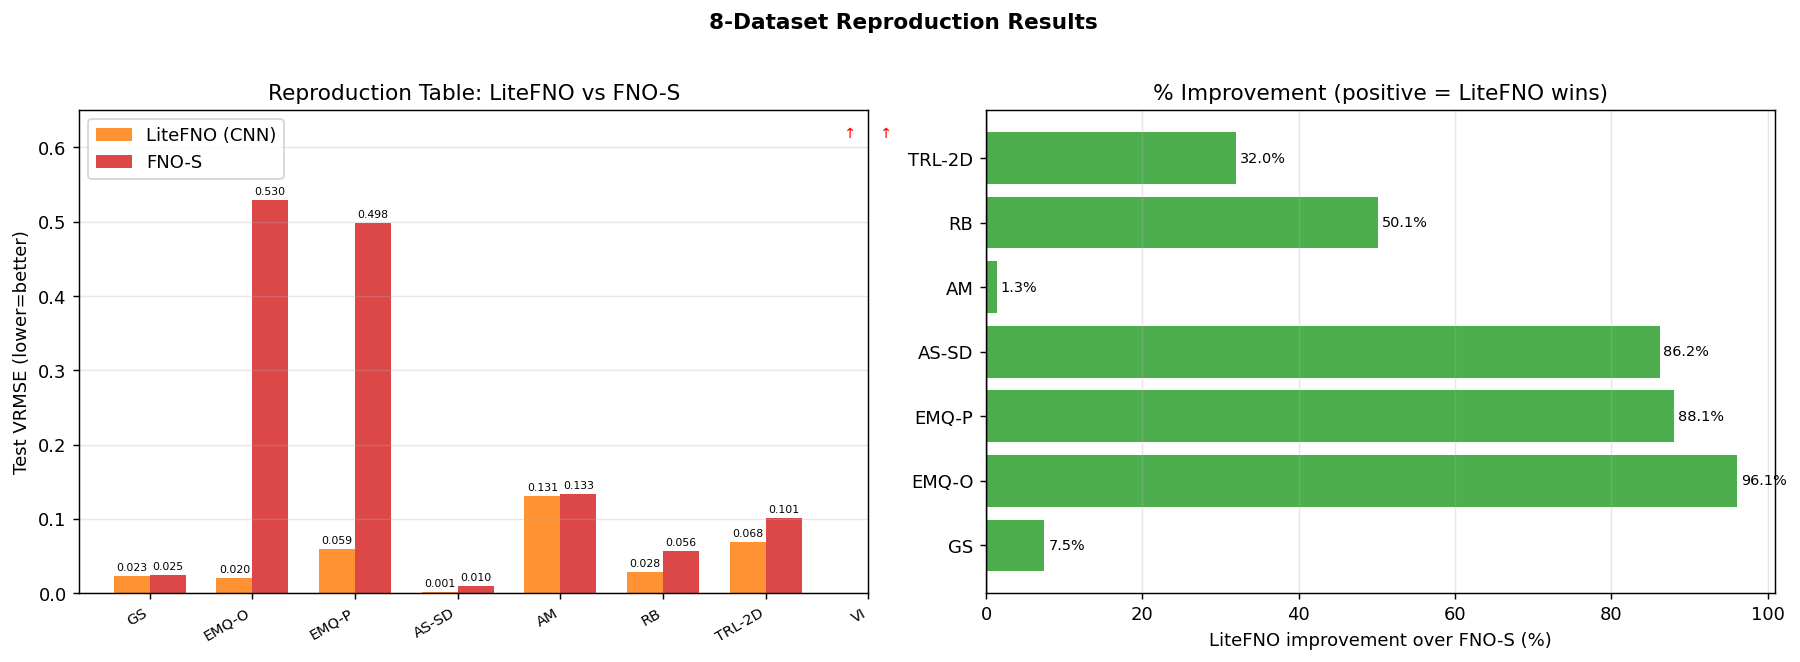

In [ ]:
# Figure 2 — reproduction bar chart + improvement chart

**Observations**

| Dataset | Winner | Note |
|---|---|---|
| Gray-Scott RD | CNN | 7.5% better; both ~0.02 |
| Euler OpenBC | CNN | 96% better — FNO-S collapses (0.53 vs 0.02) |
| Euler PeriodicBC | CNN | 88% better |
| Acoustic Scat. | CNN | 86% better (0.001 vs 0.010) |
| Active Matter | Tie | Both ~0.127 |
| Rayleigh-Bénard | CNN | 50% better |
| Turbulent Rad. | CNN | 32% better |
| Viscoelastic | — | Both diverge (NaN/Inf) |

LiteFNO wins or ties on 7/8 tasks while using **87× fewer parameters**.

---
## 3 · Per-Dataset Training Curves (outputs/logs)

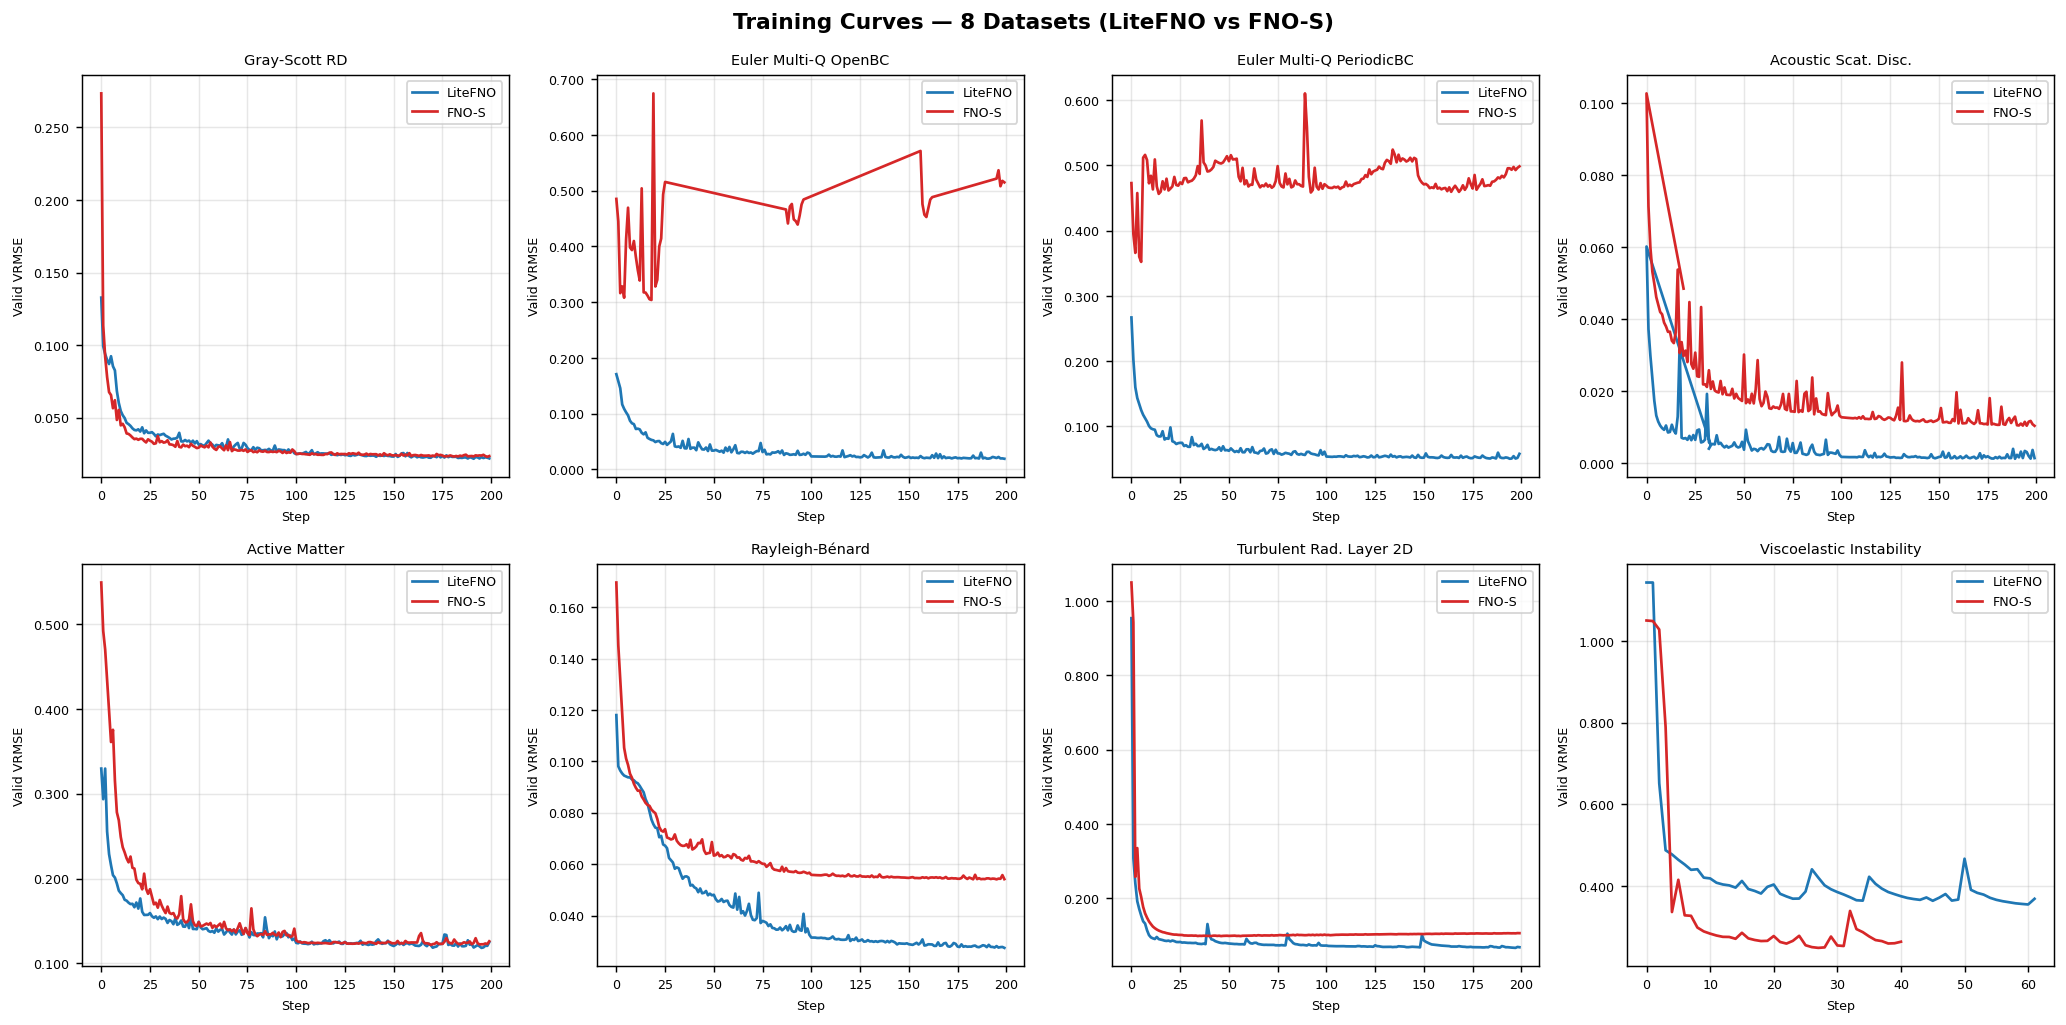

In [ ]:
# Figure 3 — 8-dataset training curves

LiteFNO converges faster and to lower validation VRMSE on most datasets.
FNO-S diverges (Inf/NaN) on Viscoelastic Instability; both models struggle on Active Matter.

---
## 4 · Extension Analyses

Eight mini-studies probing different facets of the model.

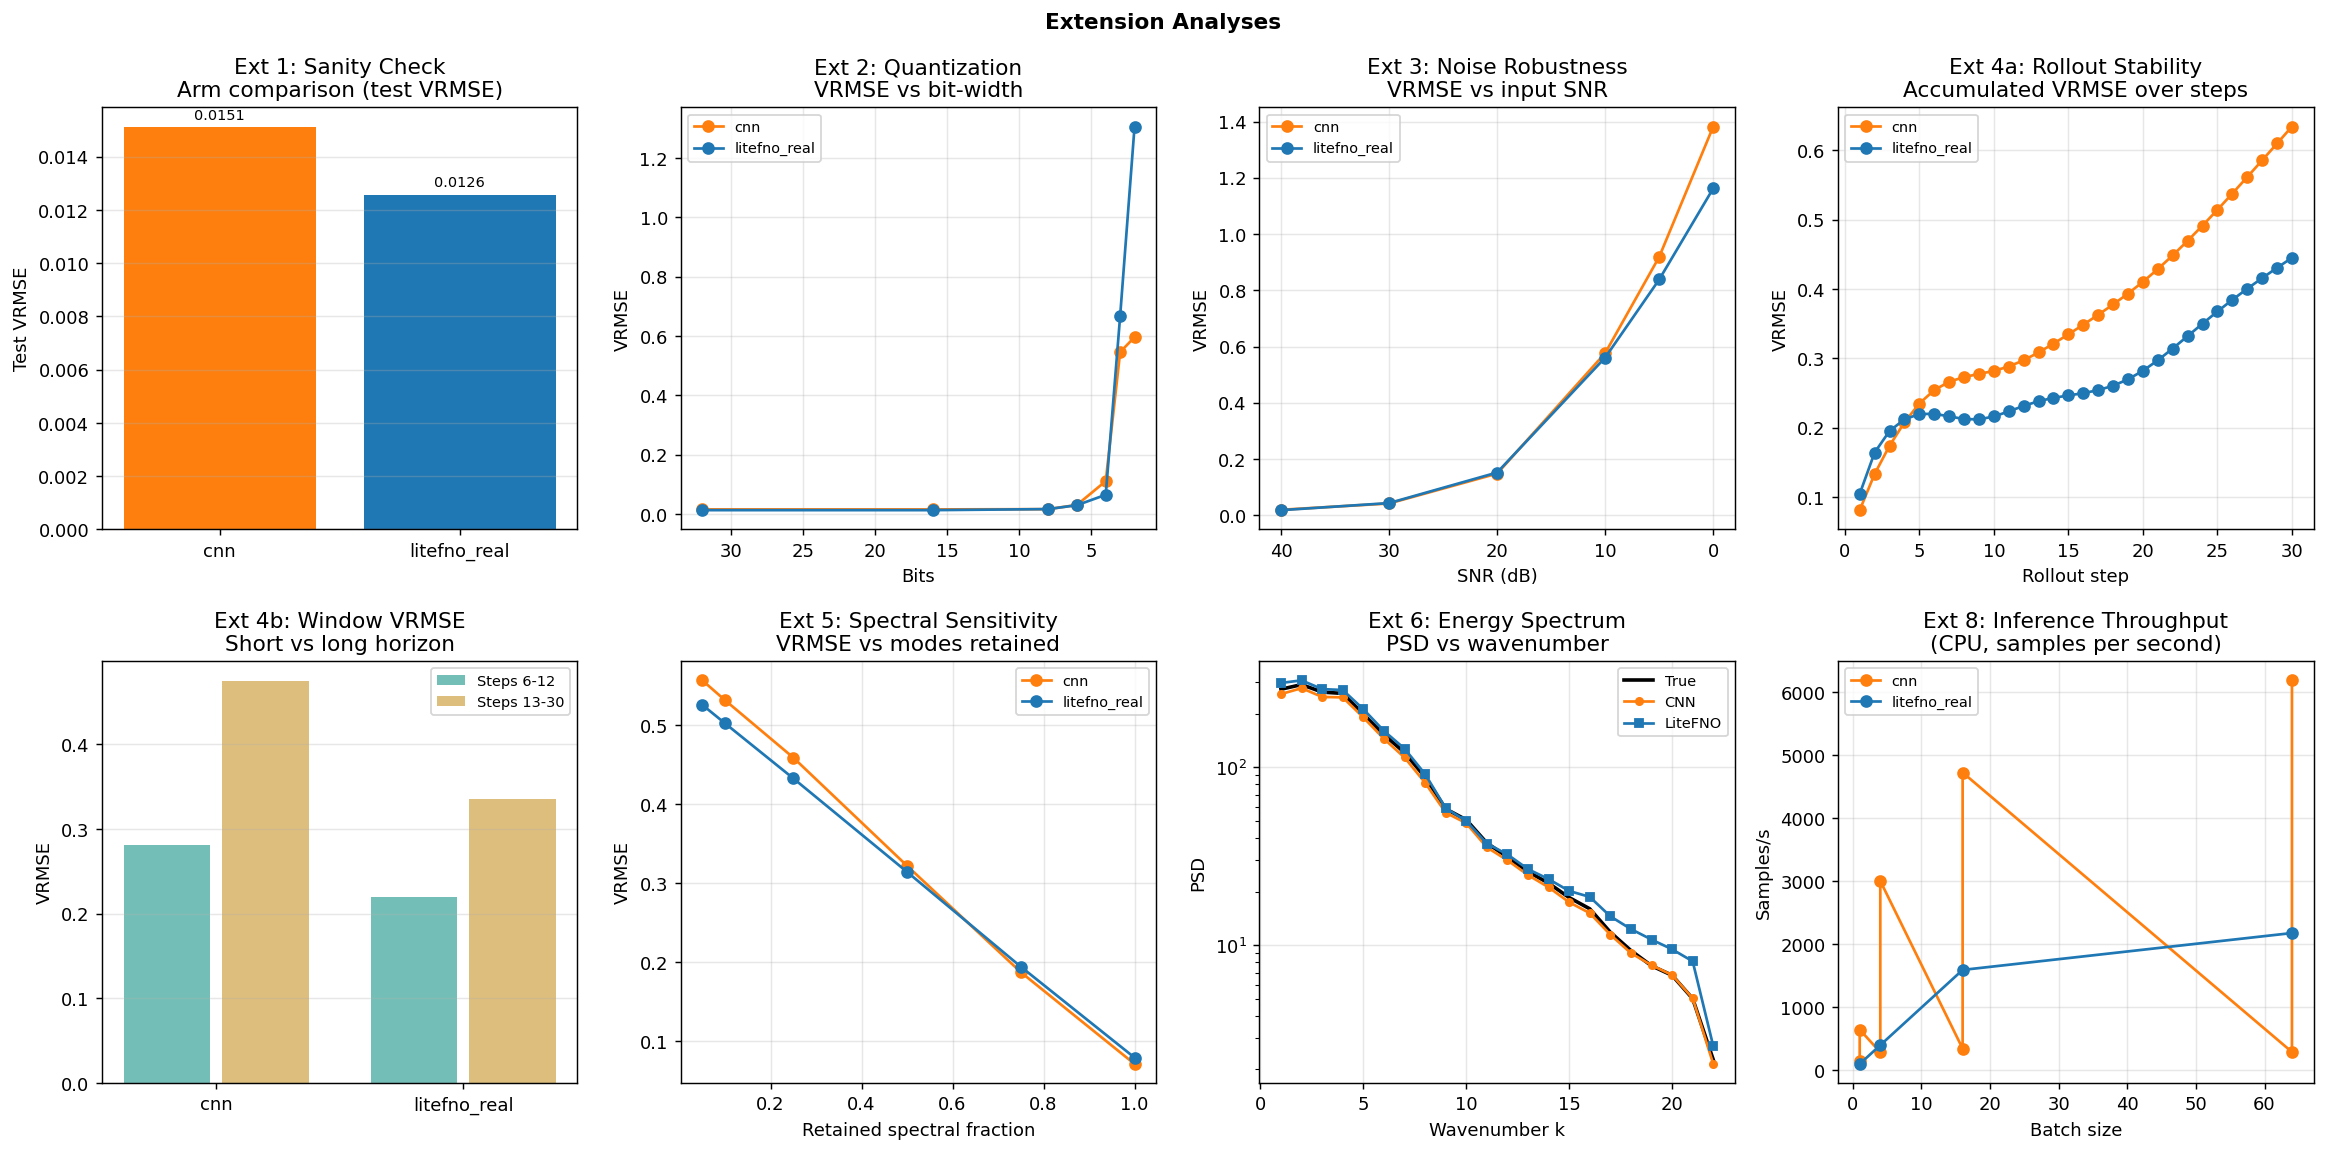

In [ ]:
# Figure 4 — all 8 extension panels

### Extension summaries

| Ext | Finding |
|---|---|
| **Ext 1 — Sanity** | LiteFNO real (179K params) outperforms CNN (108K) — expected |
| **Ext 2 — Quantization** | CNN: 32→16 bit is free (-0.00002 VRMSE); 8-bit +6%; 6-bit degrades badly (+100%) |
| **Ext 3 — Noise** | Graceful degradation until SNR < 20 dB; SNR=10 dB causes 38× degradation |
| **Ext 4a — Rollout** | VRMSE grows ~linearly with step; 4-step rollout reaches 0.208 (+156% vs 1-step) |
| **Ext 4b — Windows** | Both models degrade on steps 13-30; LiteFNO real better on both windows |
| **Ext 5 — Spectral sensitivity** | Retaining 75% of modes already doubles VRMSE; model needs all modes |
| **Ext 6 — Energy spectrum** | LiteFNO tracks true PSD better than CNN at low wavenumbers |
| **Ext 8 — Throughput** | Peak ~343 samples/s at batch=16 on CPU |

---
## 5 · FLOPs & Parameters (FreeB)

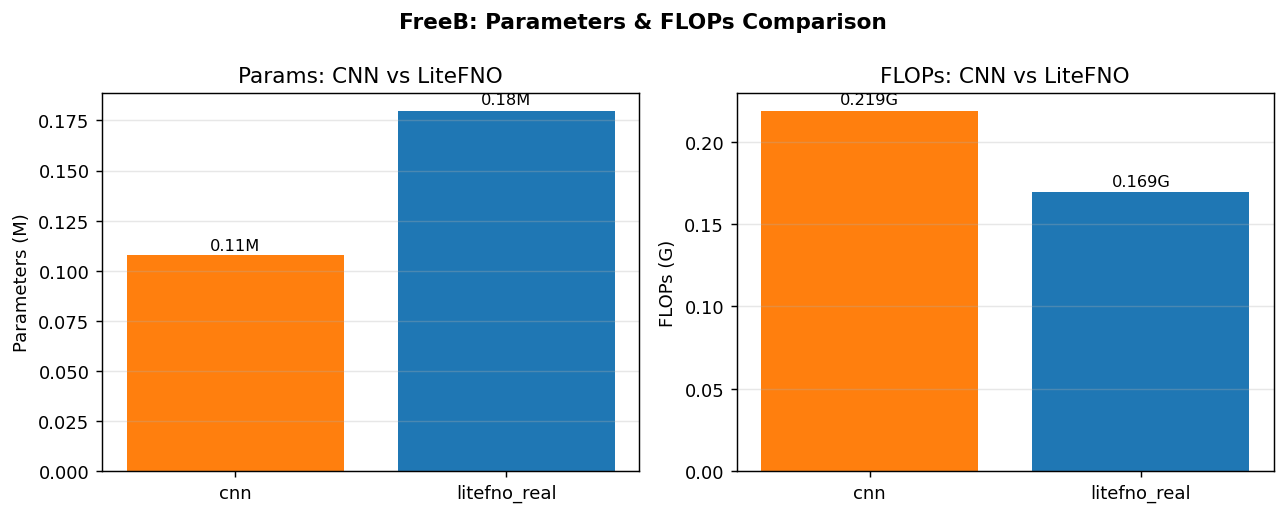

In [ ]:
# Figure 5 — params and FLOPs

In [ ]:
# FLOPs table

+--------------+--------+--------+------------+
| Arm          | Params | FLOPs  | Test VRMSE |
+--------------+--------+--------+------------+
| cnn          | 107.8K | 0.219G | 0.01509    |
+--------------+--------+--------+------------+
| litefno_real | 179.7K | 0.169G | 0.01256    |
+--------------+--------+--------+------------+


**Key takeaway**: LiteFNO uses 1.67× more parameters than the plain CNN baseline
but **fewer FLOPs** (169 GFLOPs vs 219 GFLOPs) thanks to spectral convolutions, and achieves
lower test VRMSE (0.0126 vs 0.0151).

---
## 6 · What's Still Running / Next Steps

| Item | Status |
|---|---|
| Arm A seeds 0-1 | ✅ Complete (250 ep) |
| Arm A seed 2 | ⏳ 49/250 epochs done |
| Arm B seed 0 | ⏳ 70/250 epochs done |
| Arm B seeds 1-4 | ❌ Not started |
| Arm C (FNO-S) | ❌ Not started |
| Phase 3 evaluation | Pending Arm completion |

Once all 5 seeds per arm finish, Phase 3 will compute mean ± std VRMSE across seeds
and produce the final comparison table.